# Lesson 9: Several heads + a "thinking" layer

**Why:** Lesson 8's single head spent all its effort on one pattern ("look at the previous character"), and then sent what it gathered straight to the output, with no chance to **process** it. Two fixes:

1. **Multi-head attention:** run **4 smaller heads side by side**. Each can learn a different search ("previous letter", "start of the word", "last space"...). Their results are joined together.
2. **Feed-forward layer:** after gathering, each character **thinks on its own** about what it collected. It's a small network applied to every position separately.

```
attention    = characters talk to each other    (communication)
feed-forward = each character thinks alone      (computation)
```

```
x (B,T,32) ─► 4 heads, each (B,T,8) ─► join ─► (B,T,32) ─► feed-forward ─► (B,T,32) ─► Linear ─► (B,T,85)
```

## 1. Setup (same as Lesson 8, including the `Head` class)

In [1]:
from pathlib import Path
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt

torch.manual_seed(1337)

text = Path("../data/input.txt").read_text(encoding="utf-8")
chars = sorted(set(text))
V = len(chars)
stoi = {ch: i for i, ch in enumerate(chars)}
itos = {i: ch for i, ch in enumerate(chars)}
encode = lambda s: [stoi[c] for c in s]
decode = lambda ids: "".join(itos[i] for i in ids)

data = torch.tensor(encode(text), dtype=torch.long)
n = int(0.9 * len(data))
train_data, val_data = data[:n], data[n:]

batch_size, block_size, n_embd = 32, 32, 32

def get_batch(split):
    source = train_data if split == "train" else val_data
    starts = torch.randint(len(source) - block_size, (batch_size,))
    x = torch.stack([source[i : i + block_size] for i in starts])
    y = torch.stack([source[i + 1 : i + block_size + 1] for i in starts])
    return x, y

@torch.no_grad()
def estimate_loss(model, eval_batches=100):
    model.eval()
    result = {}
    for split in ["train", "val"]:
        losses = [model(*get_batch(split))[1].item() for _ in range(eval_batches)]
        result[split] = sum(losses) / len(losses)
    model.train()
    return result

class Head(nn.Module):
    def __init__(self, head_size):
        super().__init__()
        self.query = nn.Linear(n_embd, head_size, bias=False)
        self.key = nn.Linear(n_embd, head_size, bias=False)
        self.value = nn.Linear(n_embd, head_size, bias=False)
        self.register_buffer("tril", torch.tril(torch.ones(block_size, block_size)))

    def forward(self, x):
        B, T, C = x.shape
        q, k, v = self.query(x), self.key(x), self.value(x)
        wei = q @ k.transpose(-2, -1) * k.shape[-1] ** -0.5
        wei = wei.masked_fill(self.tril[:T, :T] == 0, float("-inf"))
        wei = F.softmax(wei, dim=-1)
        self.last_wei = wei.detach()
        return wei @ v

print("ready")

ready


## 2. Multi-head attention

Instead of 1 head of size 32, we use **4 heads of size 8**. The total size is the same (4 × 8 = 32), so it costs about the same, but now there are 4 independent searches.

`nn.ModuleList` holds the heads; `torch.cat(..., dim=-1)` joins their outputs side by side along the last dimension.

In [2]:
class MultiHeadAttention(nn.Module):
    def __init__(self, num_heads, head_size):
        super().__init__()
        self.heads = nn.ModuleList([Head(head_size) for _ in range(num_heads)])

    def forward(self, x):
        return torch.cat([h(x) for h in self.heads], dim=-1)   # 4 x (B,T,8) -> (B,T,32)

mha = MultiHeadAttention(num_heads=4, head_size=8)
x = torch.randn(2, 5, n_embd)
print("each head:", mha.heads[0](x).shape)
print("joined:   ", mha(x).shape)

each head: torch.Size([2, 5, 8])
joined:    torch.Size([2, 5, 32])


## 3. The feed-forward ("thinking") layer

Two `Linear` layers with a **ReLU** between them. The first widens each character's 32 numbers to 128, giving more room to think; the second shrinks them back to 32.

**ReLU** keeps positive numbers and turns negatives into 0. That one bend is what lets the network make decisions ("if this pattern is present, then..."). Without it, two `Linear` layers in a row would collapse into one plain multiplication.

In [3]:
class FeedForward(nn.Module):
    def __init__(self, n_embd):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(n_embd, 4 * n_embd),   # (B,T,32) -> (B,T,128)
            nn.ReLU(),                       # keep positives, zero the negatives
            nn.Linear(4 * n_embd, n_embd),   # (B,T,128) -> (B,T,32)
        )

    def forward(self, x):
        return self.net(x)

print("ReLU on [-2, -0.5, 0, 0.5, 2]:", F.relu(torch.tensor([-2, -0.5, 0, 0.5, 2.0])).tolist())
print("feed-forward keeps the shape: ", FeedForward(n_embd)(x).shape)

ReLU on [-2, -0.5, 0, 0.5, 2]: [0.0, 0.0, 0.0, 0.5, 2.0]
feed-forward keeps the shape:  torch.Size([2, 5, 32])


## 4. The new model, trained on Tesla

Same as Lesson 8, with the single head swapped for 4 heads + feed-forward.

**Predict:** one head reached a validation loss of **2.31**. Will this land clearly lower (around **2.1–2.2**), about the same, or worse?

In [4]:
class MultiHeadLanguageModel(nn.Module):
    def __init__(self):
        super().__init__()
        self.tok_emb = nn.Embedding(V, n_embd)
        self.pos_emb = nn.Embedding(block_size, n_embd)
        self.attn = MultiHeadAttention(num_heads=4, head_size=n_embd // 4)   # communicate
        self.ffwd = FeedForward(n_embd)                                      # think
        self.lm_head = nn.Linear(n_embd, V)

    def forward(self, idx, targets=None):
        B, T = idx.shape
        x = self.tok_emb(idx) + self.pos_emb(torch.arange(T))   # (B,T,C)
        x = self.attn(x)                                        # (B,T,C)
        x = self.ffwd(x)                                        # (B,T,C)
        logits = self.lm_head(x)                                # (B,T,V)
        if targets is None:
            return logits, None
        loss = F.cross_entropy(logits.view(B * T, V), targets.view(B * T))
        return logits, loss

    def generate(self, idx, max_new_tokens):
        for _ in range(max_new_tokens):
            logits, _ = self(idx[:, -block_size:])
            probs = F.softmax(logits[:, -1, :], dim=-1)
            idx = torch.cat([idx, torch.multinomial(probs, 1)], dim=1)
        return idx

model = MultiHeadLanguageModel()
print("parameters:", sum(p.numel() for p in model.parameters()))

optimizer = torch.optim.AdamW(model.parameters(), lr=1e-3)
for step in range(5001):
    if step % 1000 == 0:
        l = estimate_loss(model)
        print(f"step {step:5d}:  train {l['train']:.3f}   val {l['val']:.3f}")
    xb, yb = get_batch("train")
    _, loss = model(xb, yb)
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

print("\n--- model writes ---")
print(decode(model.generate(torch.zeros((1, 1), dtype=torch.long), 400)[0].tolist()))

parameters: 17973


step     0:  train 4.484   val 4.486


step  1000:  train 2.376   val 2.389


step  2000:  train 2.123   val 2.156


step  3000:  train 1.995   val 2.028


step  4000:  train 1.898   val 1.956


step  5000:  train 1.836   val 1.903

--- model writes ---



 AThe case loyn circary circuctions
the
consuition thre fir,
of thow tho the of sone of the rimistion, ust is intangnects withs the
cor thermased be lachom, x-incithe reelatingengne a sprovider, bese the proyesce by the laizing the nonarge-of can of mach be j consideal, the dilect in ischly ream, theatusion. It low magedo bily athenserating
hiren that infromsuse
projt
of this
connary in pof apided


## 5. What does each head look at?

The same phrase as Lesson 8, one heatmap per head. If the heads learned **different jobs**, the four pictures will look different.

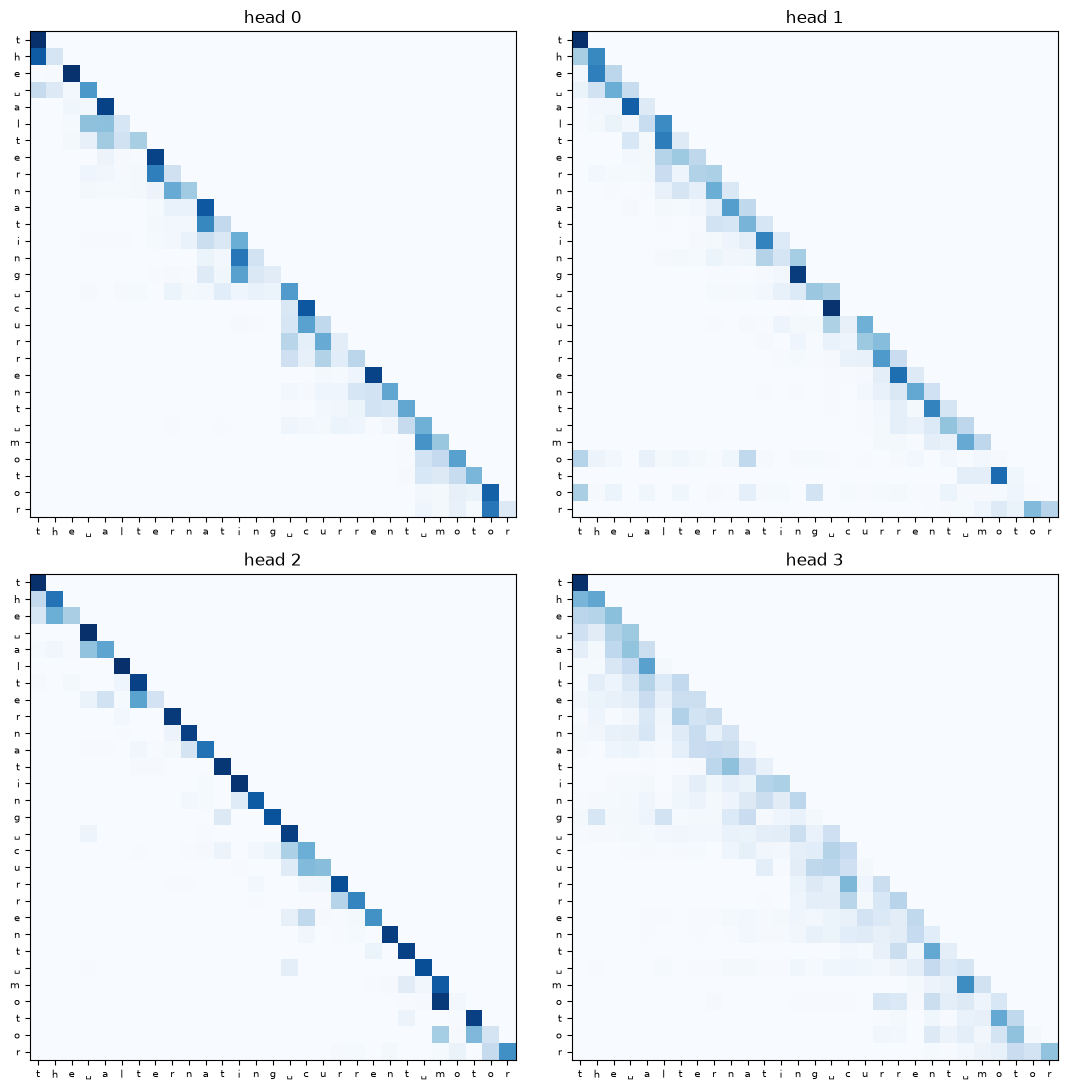

In [5]:
phrase = "the alternating current motor"
model.eval()
with torch.no_grad():
    model(torch.tensor([encode(phrase)]))
model.train()

labels = ["␣" if c == " " else c for c in phrase]
fig, axes = plt.subplots(2, 2, figsize=(11, 11))
for h, ax in enumerate(axes.flat):
    ax.imshow(model.attn.heads[h].last_wei[0], cmap="Blues")
    ax.set_xticks(range(len(labels)), labels, fontsize=7)
    ax.set_yticks(range(len(labels)), labels, fontsize=7)
    ax.set_title(f"head {h}")
plt.tight_layout(); plt.show()

## 6. Final check

In [6]:
final = estimate_loss(model, eval_batches=200)
print(f"val loss: {final['val']:.3f}   (one head: 2.31, bigram: 2.41)")
assert final["val"] < 2.31, "4 heads + feed-forward should beat one head"
print("Lesson 9 complete.")

val loss: 1.907   (one head: 2.31, bigram: 2.41)
Lesson 9 complete.


## Wrap-up question

In one sentence each: what is the job of the **attention** part, and what is the job of the **feed-forward** part?